First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

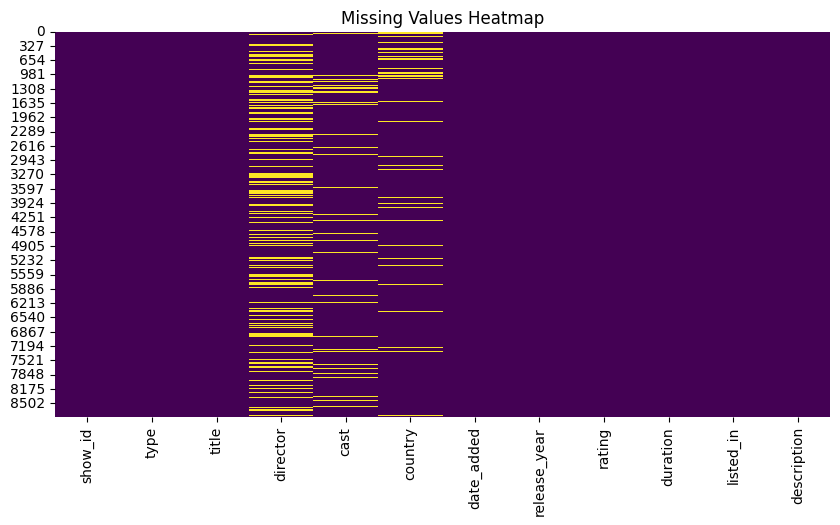


Duplicate Rows: 0


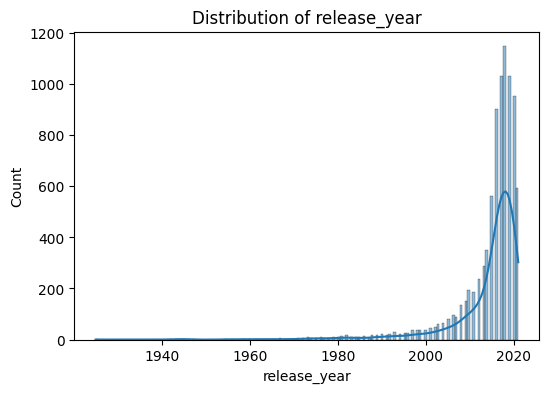

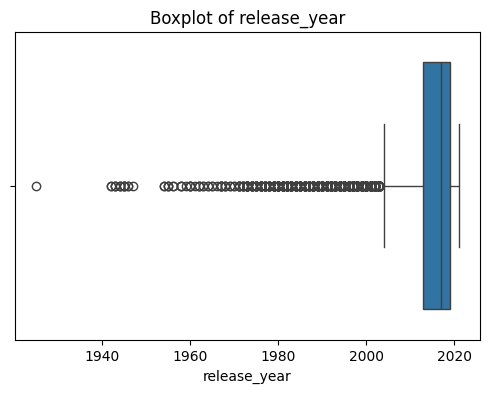

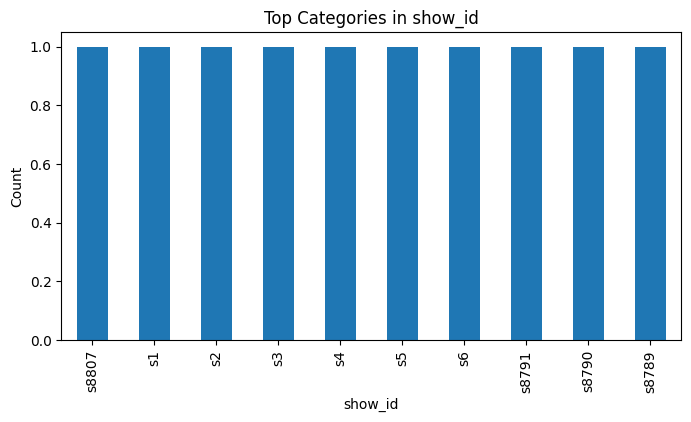

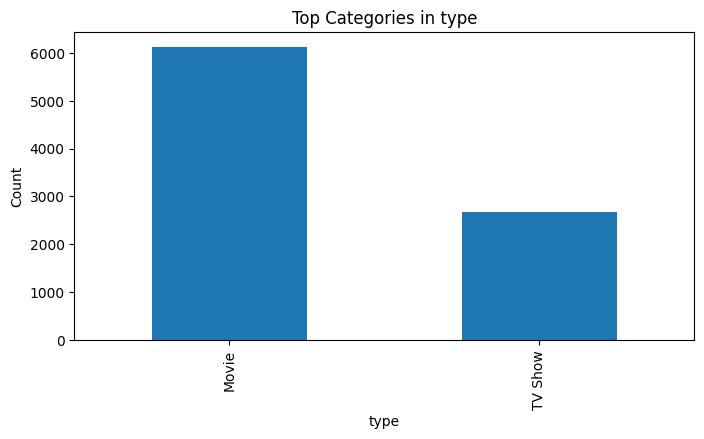

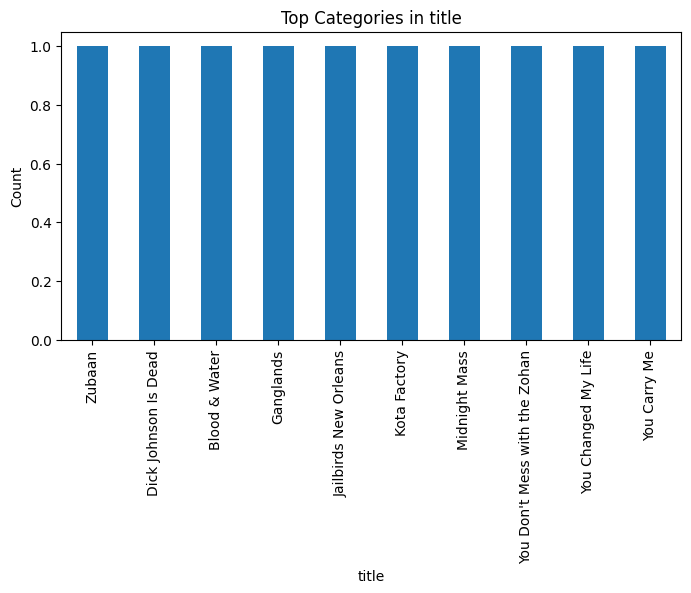

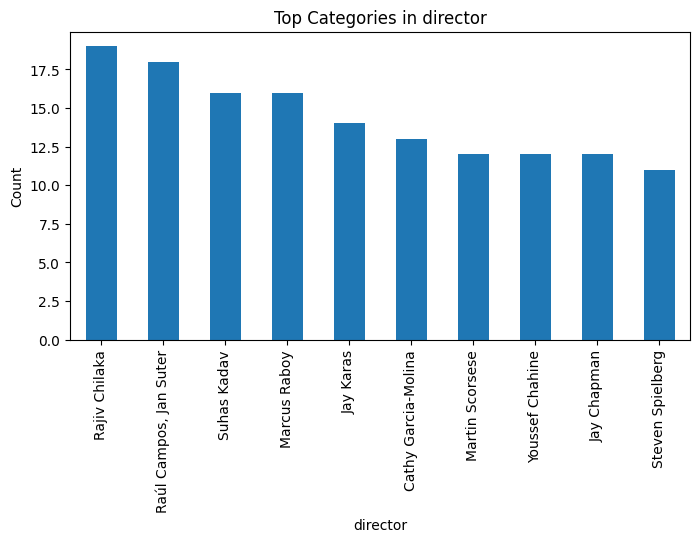

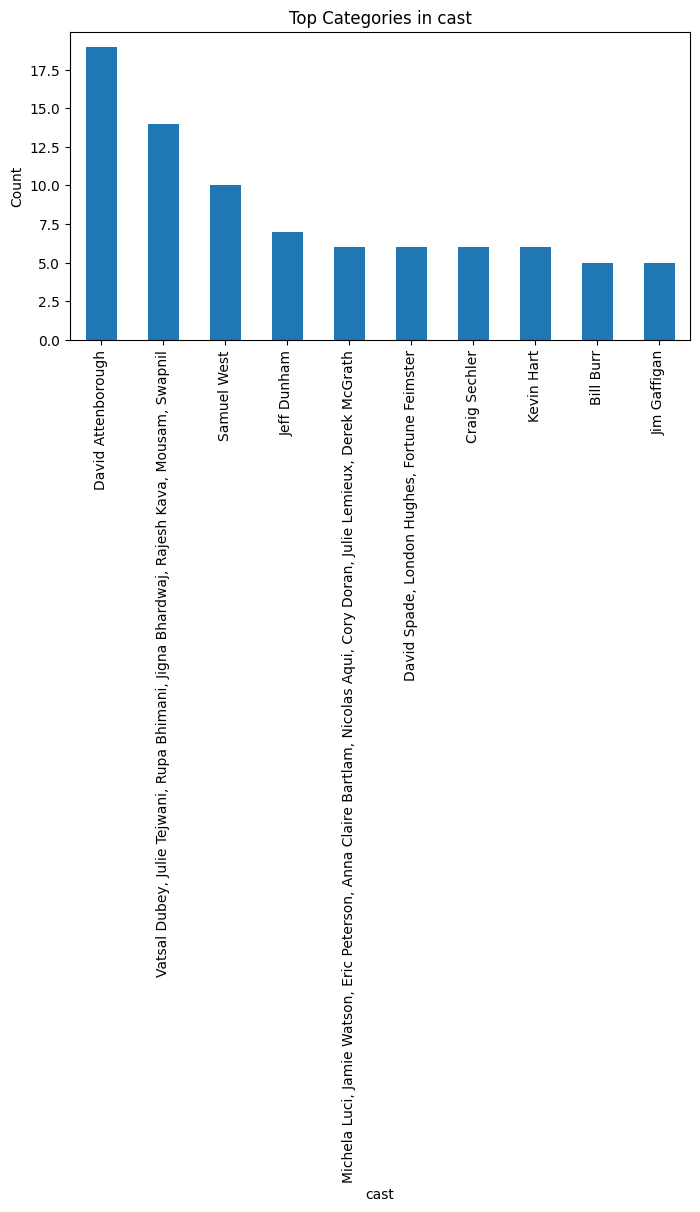

In [3]:
# Exploratory Data Analysis (EDA) Project

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
# Replace with your dataset path
df = pd.read_csv('/content/netflix_titles.csv')

# Basic Information
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))


# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

# Numerical Distributions

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Boxplots (Outlier Detection)

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


# Correlation Analysis

if len(num_cols) > 1:
    corr = df[num_cols].corr()

    plt.figure(figsize=(8,6))
    sns.heatmap(corr,
                annot=True,
                cmap='coolwarm',
                fmt='.2f')
    plt.title("Correlation Matrix")
    plt.show()

# Categorical Analysis

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols[:5]:   # first 5 categorical columns
    plt.figure(figsize=(8,4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top Categories in {col}")
    plt.ylabel("Count")
    plt.show()


# Pairplot (Numerical Columns)

if len(num_cols) > 1:
    sns.pairplot(df[num_cols])
    plt.show()


